#### Import

In [1]:
import sys
sys.path.insert(0, '..')

import torch
from src.gnn.seed import set_seed
from src.gnn.data import load_and_preprocess_data
from src.gnn.models import GCN
from src.gnn.training import compute_class_weights, train_with_early_stopping, evaluate, print_test_evaluation
from src.gnn.visualization import plot_learning_curves
from src.utils.multiseed import run_multiseed

#### Load data

In [2]:
data, device = load_and_preprocess_data('../data/processed/elliptic_pyg_data.pt', undirected=True)

Device: cpu
Data(x=[203769, 165], edge_index=[2, 468710], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


#### Define training function for one seed

In [4]:
def run_single_gcn_seed(seed):
    set_seed(seed)
    print(f"GCN Train - Seed: {seed}")
    
    model = GCN(
        in_channels=data.x.shape[1],
        hidden_channels=64,
        out_channels=2,
        dropout=0.5,
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, 
        max_lr=0.01,
        steps_per_epoch=1, 
        epochs=300,
        pct_start=0.1,
    )
    weight = compute_class_weights(data, device)
    criterion = torch.nn.CrossEntropyLoss(weight=weight)
    
    save_path = f'../saved_models/gcn_best_seed_{seed}.pt'
    history = train_with_early_stopping(
        model, data, optimizer, criterion,
        scheduler=scheduler,
        save_path=save_path,
        num_epochs=300,
        patience=30,
        monitor_metric='f1_ill',
        clip_grad_norm=1.0
    )
    
    plot_learning_curves(history, model_name=f"GCN (Seed={seed})")
    
    model.load_state_dict(torch.load(save_path))
    model.eval()
    
    print_test_evaluation(model, data, criterion, label=f"GCN Test - Seed: {seed}")
    
    test_metrics = evaluate(model, data, criterion, data.test_mask)
    return test_metrics

#### Train with multi-seed

Start training GCN

GCN - Seed: 42
GCN Train - Seed: 42
Epoch 001: Train Loss=0.8665, Val Loss=0.9344, Train F1=0.1355, Val F1=0.0410, Gap=0.0944
Epoch 002: Train Loss=0.8383, Val Loss=0.9059, Train F1=0.1442, Val F1=0.0399, Gap=0.1043
Epoch 003: Train Loss=0.8176, Val Loss=0.8742, Train F1=0.1573, Val F1=0.0418, Gap=0.1155
Epoch 004: Train Loss=0.7804, Val Loss=0.8366, Train F1=0.1712, Val F1=0.0443, Gap=0.1269
Epoch 005: Train Loss=0.7595, Val Loss=0.7918, Train F1=0.1909, Val F1=0.0472, Gap=0.1437
Epoch 006: Train Loss=0.7295, Val Loss=0.7391, Train F1=0.2165, Val F1=0.0522, Gap=0.1643
Epoch 007: Train Loss=0.6596, Val Loss=0.6799, Train F1=0.2553, Val F1=0.0646, Gap=0.1907
Epoch 008: Train Loss=0.6023, Val Loss=0.6183, Train F1=0.3152, Val F1=0.0813, Gap=0.2339
Epoch 009: Train Loss=0.5816, Val Loss=0.5615, Train F1=0.4048, Val F1=0.1123, Gap=0.2925
Epoch 010: Train Loss=0.5083, Val Loss=0.5181, Train F1=0.4706, Val F1=0.1590, Gap=0.3116
Epoch 011: Train Loss=0.4709, Val Loss=0.495

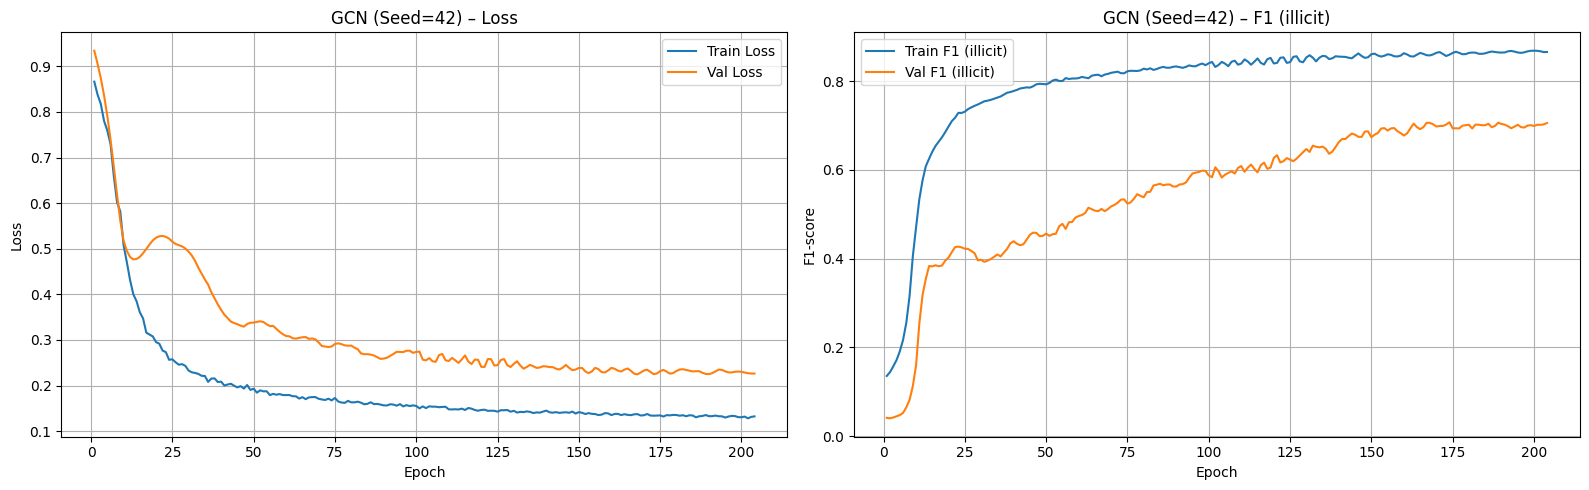

GCN Test - Seed: 42
  Loss          : 0.4099
  Accuracy      : 0.9407
  Precision(ill): 0.8576
  Recall(ill)   : 0.4617
  F1(illicit)   : 0.6002
  F1(macro)     : 0.7841
  AUC-PR        : 0.6859
Classification Report:
              precision    recall  f1-score   support

   Licit (0)     0.9452    0.9918    0.9680      5132
 Illicit (1)     0.8576    0.4617    0.6002       548

    accuracy                         0.9407      5680
   macro avg     0.9014    0.7267    0.7841      5680
weighted avg     0.9368    0.9407    0.9325      5680

Confusion Matrix:
[[5090   42]
 [ 295  253]]

GCN - Seed: 0
GCN Train - Seed: 0
Epoch 001: Train Loss=0.6424, Val Loss=0.7770, Train F1=0.0917, Val F1=0.0458, Gap=0.0459
Epoch 002: Train Loss=0.6291, Val Loss=0.7687, Train F1=0.1162, Val F1=0.0552, Gap=0.0610
Epoch 003: Train Loss=0.6281, Val Loss=0.7592, Train F1=0.1484, Val F1=0.0795, Gap=0.0689
Epoch 004: Train Loss=0.6093, Val Loss=0.7482, Train F1=0.1825, Val F1=0.1221, Gap=0.0604
Epoch 005: Trai

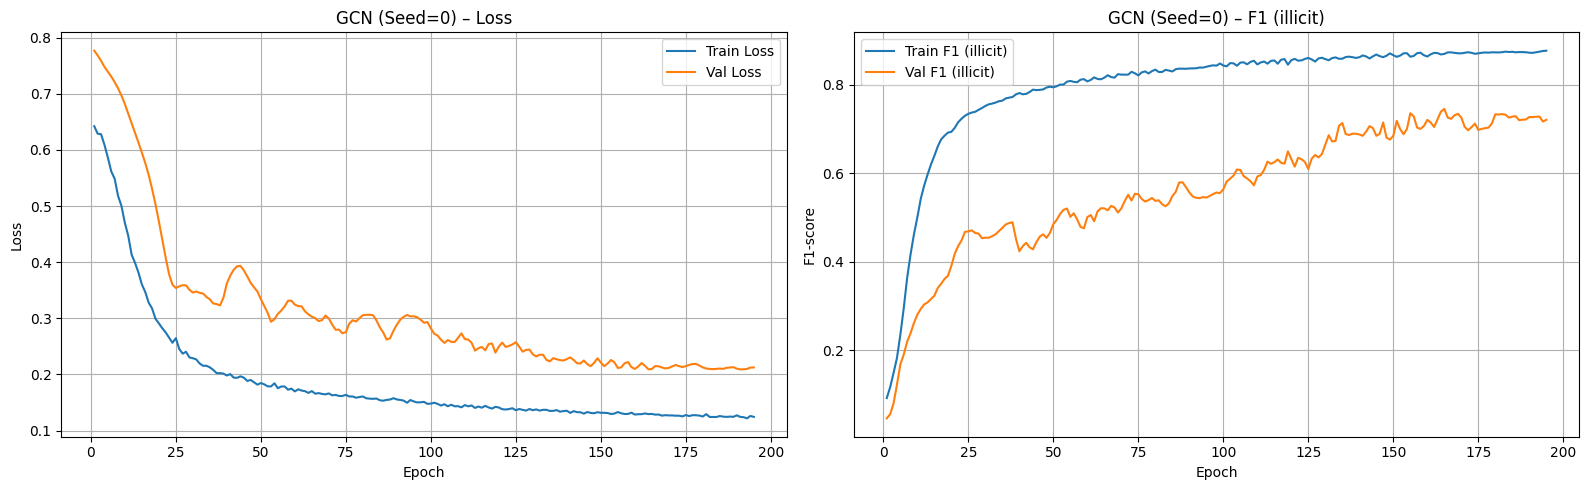

GCN Test - Seed: 0
  Loss          : 0.3845
  Accuracy      : 0.9454
  Precision(ill): 0.8696
  Recall(ill)   : 0.5109
  F1(illicit)   : 0.6437
  F1(macro)     : 0.8071
  AUC-PR        : 0.7272
Classification Report:
              precision    recall  f1-score   support

   Licit (0)     0.9500    0.9918    0.9704      5132
 Illicit (1)     0.8696    0.5109    0.6437       548

    accuracy                         0.9454      5680
   macro avg     0.9098    0.7514    0.8071      5680
weighted avg     0.9422    0.9454    0.9389      5680

Confusion Matrix:
[[5090   42]
 [ 268  280]]

GCN - Seed: 123
GCN Train - Seed: 123
Epoch 001: Train Loss=1.3084, Val Loss=2.7642, Train F1=0.1154, Val F1=0.0627, Gap=0.0527
Epoch 002: Train Loss=1.2927, Val Loss=2.6718, Train F1=0.1148, Val F1=0.0636, Gap=0.0511
Epoch 003: Train Loss=1.2052, Val Loss=2.5629, Train F1=0.1137, Val F1=0.0626, Gap=0.0511
Epoch 004: Train Loss=1.1951, Val Loss=2.4258, Train F1=0.1124, Val F1=0.0633, Gap=0.0491
Epoch 005: T

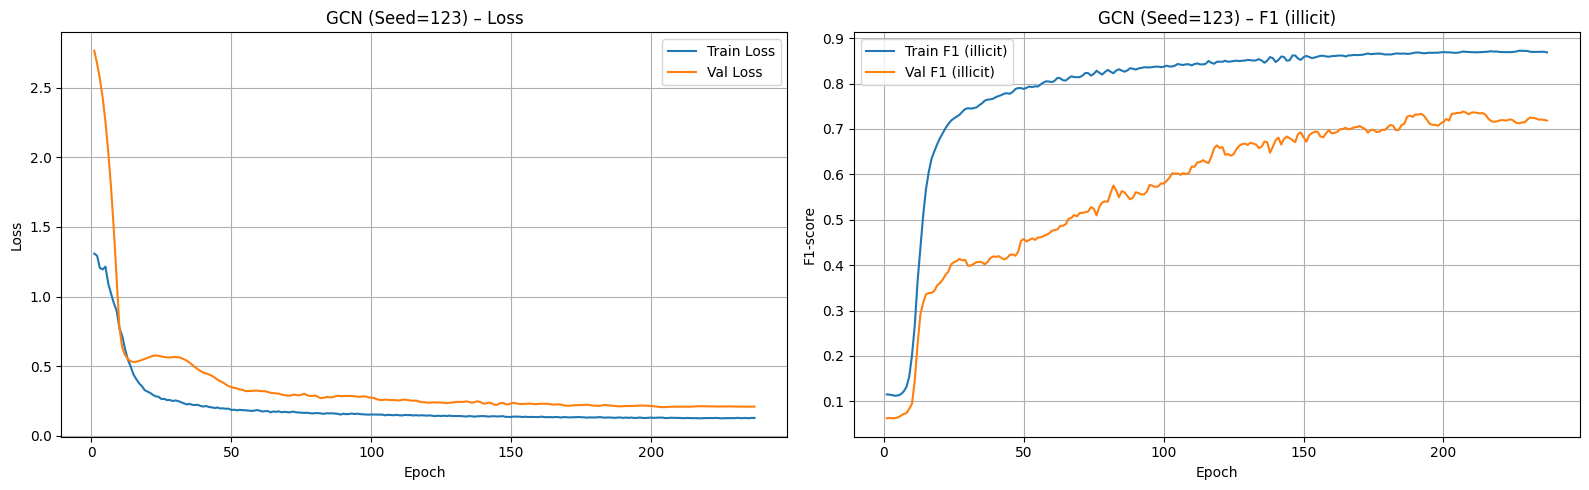

GCN Test - Seed: 123
  Loss          : 0.3783
  Accuracy      : 0.9468
  Precision(ill): 0.8705
  Recall(ill)   : 0.5274
  F1(illicit)   : 0.6568
  F1(macro)     : 0.8140
  AUC-PR        : 0.7284
Classification Report:
              precision    recall  f1-score   support

   Licit (0)     0.9516    0.9916    0.9712      5132
 Illicit (1)     0.8705    0.5274    0.6568       548

    accuracy                         0.9468      5680
   macro avg     0.9110    0.7595    0.8140      5680
weighted avg     0.9437    0.9468    0.9409      5680

Confusion Matrix:
[[5089   43]
 [ 259  289]]

 GCN multi-seed results
Loss       : 0.3909 ± 0.0137
Accuracy   : 0.9443 ± 0.0026
Precision_ill: 0.8659 ± 0.0059
Recall_ill : 0.5000 ± 0.0279
F1(illicit): 0.6336 ± 0.0242
F1_macro   : 0.8017 ± 0.0128
AUC-PR     : 0.7138 ± 0.0197


In [5]:
print("Start training GCN")
results = run_multiseed(run_single_gcn_seed, "GCN", seeds=[42, 0, 123])